In [ ]:
!pip install b3lien

In [6]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import sparse
import dask.array as da
import numpy as np

from pyproj import Proj, Transformer
from shapely.geometry import mapping
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Load the GRIIS checklist

checklist_path = "./data/dwca-unified-checklist-v1.15/"
distribution = checklist_path + "distribution.txt"

df_cl = pd.read_csv(distribution, sep='\t', low_memory=False)

In [3]:
# Specific issue due to the Belgian checklist
df_cl["speciesKey"] = df_cl["id"].str.rsplit("/", n=1).str[-1].astype("int64")

In [4]:
# 1. Filter rows where locality == 'Belgium' and eventDate is not missing
df = df_cl[df_cl["locality"] == "Belgium"].copy()
df = df[df["eventDate"].notna()]

# 2. Split eventDate into intro and outro (assuming 'YYYY/MM' or 'YYYY/MM/YYYY/MM')
def split_event_date(x):
    if isinstance(x, str):
        parts = x.strip().split('/')
        if len(parts) == 2:
            intro = parts[0]
            outro = parts[1]
        else:
            intro = outro = np.nan
        return pd.Series([intro, outro])
    else:
        return pd.Series([np.nan, np.nan])

df[["introDate", "outroDate"]] = df["eventDate"].apply(split_event_date)

df["introDate"] = pd.to_datetime(df["introDate"], format="%Y", errors="coerce")
df["outroDate"] = pd.to_datetime(df["outroDate"], format="%Y", errors="coerce")


# 3. Clean rows with missing introDate
df_intro = df.dropna(subset=["introDate"]).copy()

# 4. Group by introDate and count species
in_species = (
    df_intro.groupby("introDate", sort=True)["id"]
    .count()
    .reset_index(name="nspec")
)

# 5. Cumulative sum
in_species["cumn"] = in_species["nspec"].cumsum()

# 6. Clean outro side and count outgoing species
df_outro = df.dropna(subset=["outroDate"]).copy()

out_species = (
    df_outro.groupby("outroDate", sort=True)["id"]
    .count()
    .reset_index(name="nspeco")
)

# 7. Merge intro and outro on date
n_species = pd.merge(in_species, out_species, how="outer", left_on="introDate", right_on="outroDate")

# 8. Replace NaNs with 0
n_species["nspec"] = n_species["nspec"].fillna(0).astype(int)
n_species["nspeco"] = n_species["nspeco"].fillna(0).astype(int)

# 9. Net species present at each time step
n_species["total"] = n_species["nspec"] - n_species["nspeco"]

# 10. Final frame with total species over time
tot_species = n_species[["introDate", "total"]].copy()

# 11. Optional: sort and compute cumulative total over time
tot_species = tot_species.sort_values("introDate")
tot_species["cumulative_total"] = tot_species["total"].cumsum()

In [9]:
in_species

,introDate,nspec,cumn,time,cumulative_species
0,1680-01-01,1,1,1680-01-01,1
1,1700-01-01,2,3,1700-01-01,3
2,1701-01-01,1,4,1701-01-01,4
3,1711-01-01,1,5,1711-01-01,5
4,1730-01-01,1,6,1730-01-01,6
...,...,...,...,...,...
216,2021-01-01,90,3830,2021-01-01,3830
217,2022-01-01,106,3936,2022-01-01,3936
218,2023-01-01,47,3983,2023-01-01,3983
219,2024-01-01,2,3985,2024-01-01,3985


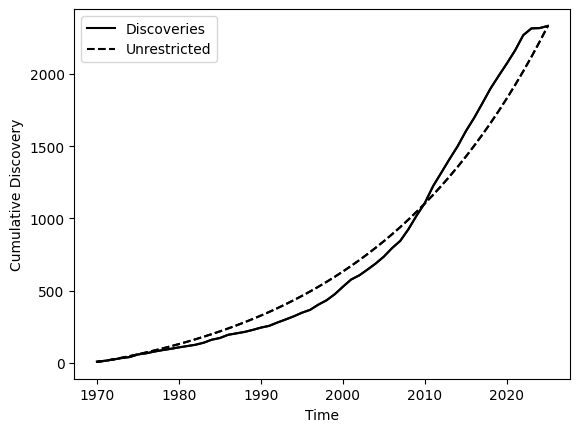

In [7]:
from b3alien import b3cube
from b3alien import griis
from b3alien import simulation

def filter_time_window(df, start_year, end_year):
    """Filter time and rate based on year window."""
    filtered = df[(df["year"] >= start_year) & (df["year"] <= end_year)].reset_index(drop=True)
    return filtered["year"], filtered["rate"]


in_species["time"] = pd.to_datetime(in_species["introDate"])
in_species["cumulative_species"] = in_species["cumn"]

time, rate = b3cube.calculate_rate(in_species)


df = pd.DataFrame({
    "year": time,
    "rate": rate
})

time, rate = filter_time_window(df, 1970, 2025)

C1, vec1 = simulation.simulate_solow_costello_scipy(time, rate, vis=True)

Bootstrapping: 100%|██████████| 200/200 [00:41<00:00,  4.78it/s]


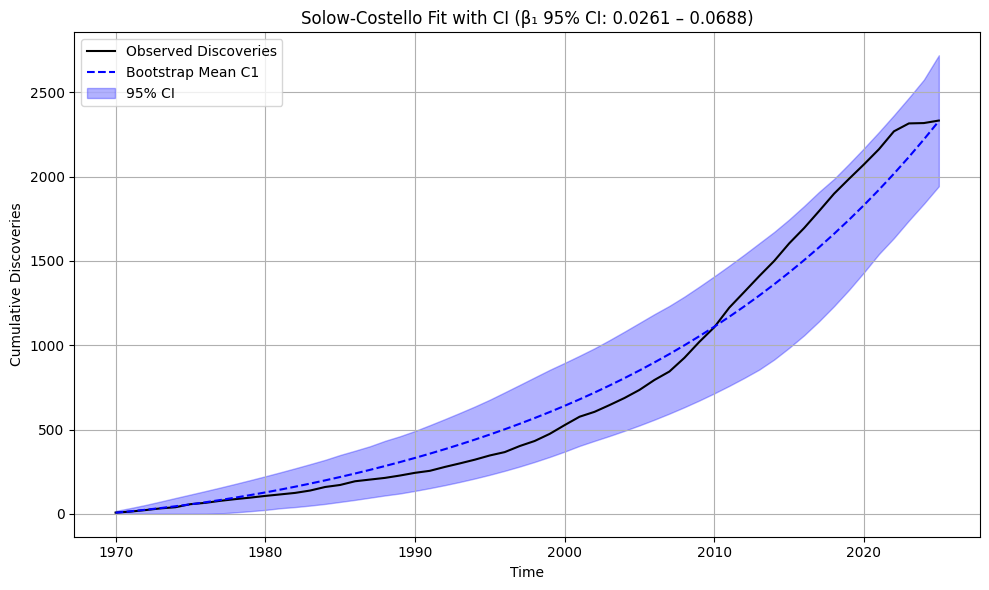

In [8]:
results = simulation.parallel_bootstrap_solow_costello(time, rate, n_iterations=200)

simulation.plot_with_confidence(time, rate, results)

In [10]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# ==============================================================================
# 1. SETUP: Ensure your results dictionary is available here.
# Replace 'results' with the actual variable name from your notebook if different.
# ==============================================================================
# Example: results = my_bootstrap_output_variable

# If you need to test with the snippet provided (WARNING: Truncated data will fail fitting),
# you would uncomment the lines below, but for real analysis, use your actual variable.
# from numpy import array
# results = { ... paste your dict here if strictly necessary ... }


# ==============================================================================
# 2. DEFINITIONS
# ==============================================================================

def solow_costello_cdf(t, beta0, beta1, beta2):
    """
    Cumulative species description: S(t) = b0 + b1 * ln(1 + b2 * t)
    """
    # Safety against invalid log inputs
    val = 1 + beta2 * t
    val = np.maximum(val, 1e-9)
    return beta0 + beta1 * np.log(val)

def calculate_annual_rates(results_dict, start_year=1970, target_years=None):
    if target_years is None:
        target_years = [2020, 2021, 2022, 2023, 2024, 2025]

    c1_all = np.array(results_dict['c1_all'])
    n_boot, n_time = c1_all.shape

    # Create time array (0, 1, 2...) matching the data length
    time_arr = np.arange(n_time)

    print(f"Processing {n_boot} curves...")
    print(f"Data spans {n_time} years (approx {start_year} to {start_year + n_time - 1})")

    # Container for rates: {2020: [r1, r2...], 2021: [...]}
    year_rates = {yr: [] for yr in target_years}

    # Initial guess for solver [beta0, beta1, beta2]
    # b0=0, b1=slope~10, b2=small decay~0.05
    p0 = [0.0, 10.0, 0.05]

    successful_fits = 0

    for i in range(n_boot):
        curve = c1_all[i]

        try:
            # Fit the model to this specific bootstrap curve to recover its exact beta2
            # We constrain beta1 and beta2 to be positive
            popt, _ = curve_fit(
                solow_costello_cdf,
                time_arr,
                curve,
                p0=p0,
                bounds=((-np.inf, 0, 0), (np.inf, np.inf, np.inf)),
                maxfev=2000
            )

            b1_fit, b2_fit = popt[1], popt[2]

            # Calculate Rate for each target year
            # Rate(t) = (b1 * b2) / (1 + b2 * t)
            for yr in target_years:
                t_model = yr - start_year

                # Check if year is valid relative to model start
                if t_model < 0:
                    year_rates[yr].append(np.nan)
                else:
                    denom = 1 + b2_fit * t_model
                    rate = (b1_fit * b2_fit) / denom
                    year_rates[yr].append(rate)

            successful_fits += 1

        except Exception:
            # If fit fails, skip or append nan
            for yr in target_years:
                year_rates[yr].append(np.nan)

    print(f"Successfully fit {successful_fits}/{n_boot} curves.")

    # Compile Statistics
    summary_data = []
    for yr in target_years:
        rates = np.array(year_rates[yr])
        rates = rates[~np.isnan(rates)] # Remove failures

        if len(rates) > 0:
            mean_r = np.mean(rates)
            ci_lo, ci_hi = np.percentile(rates, [2.5, 97.5])
            std_r = np.std(rates, ddof=1)

            summary_data.append({
                "Year": yr,
                "Effective Rate (Mean)": mean_r,
                "CI Lower (2.5%)": ci_lo,
                "CI Upper (97.5%)": ci_hi,
                "Std Dev": std_r
            })
        else:
            summary_data.append({"Year": yr, "Effective Rate (Mean)": np.nan})

    return pd.DataFrame(summary_data)

# ==============================================================================
# 3. EXECUTION
# ==============================================================================

# NOTE: Adjust start_year if your dataset does not start in 1970.
# Based on your data length (53) and context (filtering from 1970),
# 1970 is the most likely start year.
df_rates = calculate_annual_rates(results, start_year=1970)

# Display nicely
print("\n=== Solow-Costello Effective Annual Rates ===")
print(df_rates.round(4).to_string(index=False))

Processing 200 curves...
Data spans 56 years (approx 1970 to 2025)
Successfully fit 200/200 curves.

=== Solow-Costello Effective Annual Rates ===
 Year  Effective Rate (Mean)  CI Lower (2.5%)  CI Upper (97.5%)  Std Dev
 2020                39.0746          31.0710           45.8827   4.0098
 2021                39.0746          31.0710           45.8826   4.0098
 2022                39.0745          31.0710           45.8826   4.0097
 2023                39.0745          31.0709           45.8825   4.0097
 2024                39.0744          31.0709           45.8825   4.0097
 2025                39.0744          31.0709           45.8824   4.0097


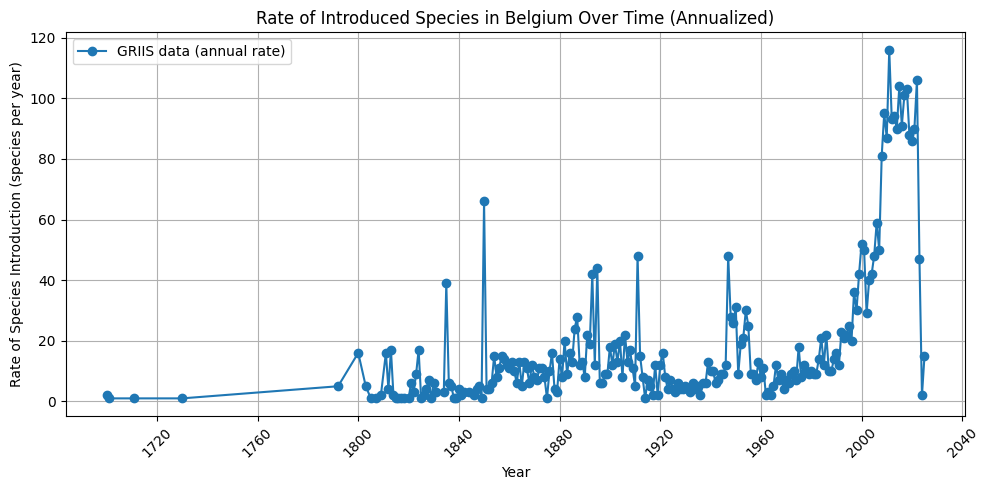

In [11]:
# --- Processing GRIIS data (Annual) ---
in_species["introDate"] = pd.to_datetime(in_species["introDate"])
in_species_rate = in_species.sort_values(by="introDate").copy()
in_species_rate["rate_per_year"] = in_species_rate["cumn"].diff()


# --- Plotting the rate of species (per year) ---
plt.figure(figsize=(10, 5))
#plt.plot(pd.to_datetime(annual_time_gbif, format='%Y'), annual_rate_gbif_series, marker="x", label="GBIF data (approx. annual rate)")
plt.plot(in_species_rate["introDate"][1:], in_species_rate["rate_per_year"][1:], marker="o", label="GRIIS data (annual rate)")
plt.title("Rate of Introduced Species in Belgium Over Time (Annualized)")
plt.xlabel("Year")
plt.ylabel("Rate of Species Introduction (species per year)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()